In [52]:
# !For this plot a functioning LaTeX installation must be on the computer

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import os

# set plot size to (16, 9)
plt.rcParams['figure.figsize'] = [16, 9]

In [2]:
if not os.path.isdir('figures'):
    os.mkdir('figures')

In [3]:
def ratio(pop_total, pop_alive, conf):
    if pop_total == 0:
        return 0
    elif conf == 0:
        return 1
    else:
        return min(shell(pop_total, conf) / pop_alive, 1)
    
def shell(pop_total, conf):
    return pop_total - 4/3*np.pi * (core(pop_total, conf))**3
                                                   
def core(pop_total, conf):
    return max((3/4*(pop_total)/np.pi)**(1/3) - 1/conf, 0)

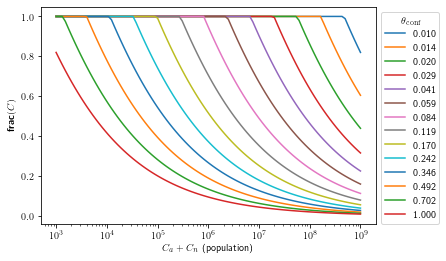

In [4]:
# log scaled array from 0.01 to 1.0 with 16 steps
conf = np.logspace(np.log10(0.01), np.log10(1.0), 14)

# log scaled array from 1000 to 10^9 with 100 steps
pop = np.logspace(3, 9, 100)

# Plot
plt.xscale('log')
plt.xlabel('$C_a + C_n$ (population)')
plt.ylabel(r'$\textbf{frac}(C)$')
for con in conf:
    plt.plot(pop, np.array([ratio(p, p / 2, con) for p in pop]))

# create an artist for the legend
legend_elements = ['{:.3f}'.format(c) for c in conf]

# plot legend from the artist outside of the plot with anchor top right and text "confinement"
plt.legend(legend_elements, loc='upper left', title='$\\theta_{\\rm{conf}}$',  bbox_to_anchor=(1, 1))

# save the plot as a PDF
plt.savefig('figures/confinement.pdf', bbox_inches = 'tight')

# save the plot as a Png
plt.savefig('figures/confinement.png', bbox_inches = 'tight')

In [27]:
def sum_fit(iterations, value):
    res = [1]
    for i in range(iterations - 1):
        res.append(res[-1] + value)
    return res     

def mul_fit(iterations, value):
    res = [1]
    for i in range(iterations - 1):
        res.append(res[-1] * (1 + value))
    return res     

def eth_fit(iterations, value):
    MAX_FIT = 10
    res = [1]
    for i in range(iterations - 1):
        res.append(res[-1] * (1 + value * (1 - res[-1] / MAX_FIT)))
    return res

def log_mul_fit(iterations, value):
    return [1 + np.log(x) for x in mul_fit(iterations, value)]

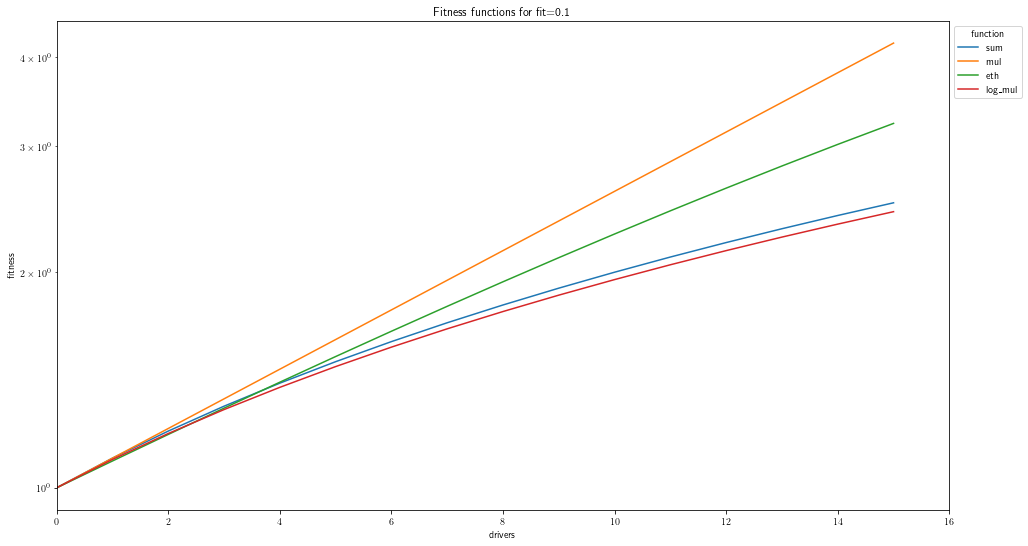

In [59]:
steps = list(range(0, 16))

fit = 0.1
plt.plot(steps, sum_fit(16, fit))
plt.plot(steps, mul_fit(16, fit))
plt.plot(steps, eth_fit(16, fit))
plt.plot(steps, log_mul_fit(16, fit))

plt.yscale('log')
plt.ylabel('fitness')
plt.xlabel('drivers')
plt.xlim(0, 16)
plt.legend(['sum', 'mul', 'eth', 'log_mul'], loc='upper left', title='function',  bbox_to_anchor=(1, 1))

# title 
plt.title(f'Fitness functions for fit={fit}')

# save the plot as a PNG   
plt.savefig('figures/fitness_functions1.png', bbox_inches = 'tight')

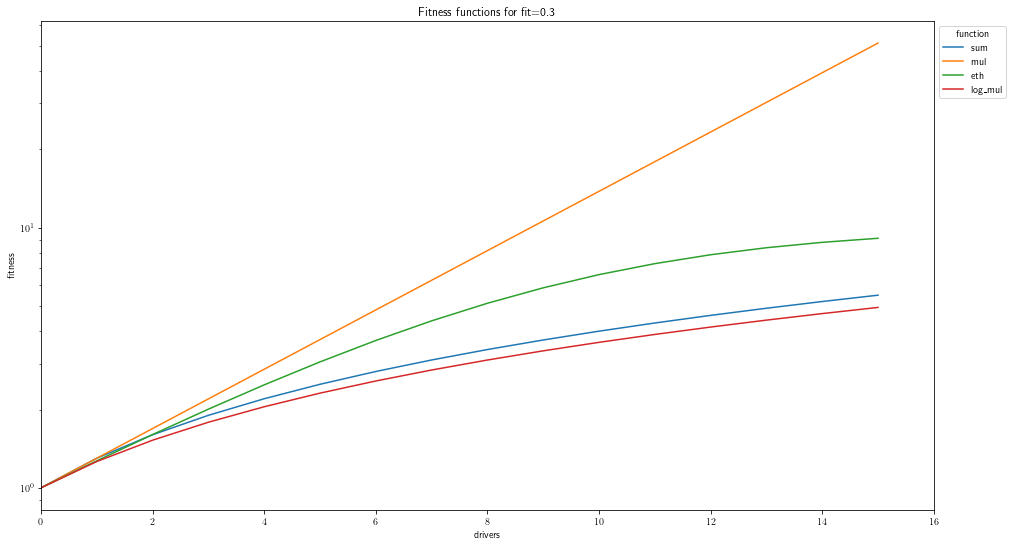

In [60]:
steps = list(range(0, 16))

fit = 0.3
plt.plot(steps, sum_fit(16, fit))
plt.plot(steps, mul_fit(16, fit))
plt.plot(steps, eth_fit(16, fit))
plt.plot(steps, log_mul_fit(16, fit))

plt.yscale('log')
plt.ylabel('fitness')
plt.xlabel('drivers')
plt.xlim(0, 16)
plt.legend(['sum', 'mul', 'eth', 'log_mul'], loc='upper left', title='function',  bbox_to_anchor=(1, 1))

# title 
plt.title(f'Fitness functions for fit={fit}')

# save the plot as a PNG   
plt.savefig('figures/fitness_functions2.png', bbox_inches = 'tight')


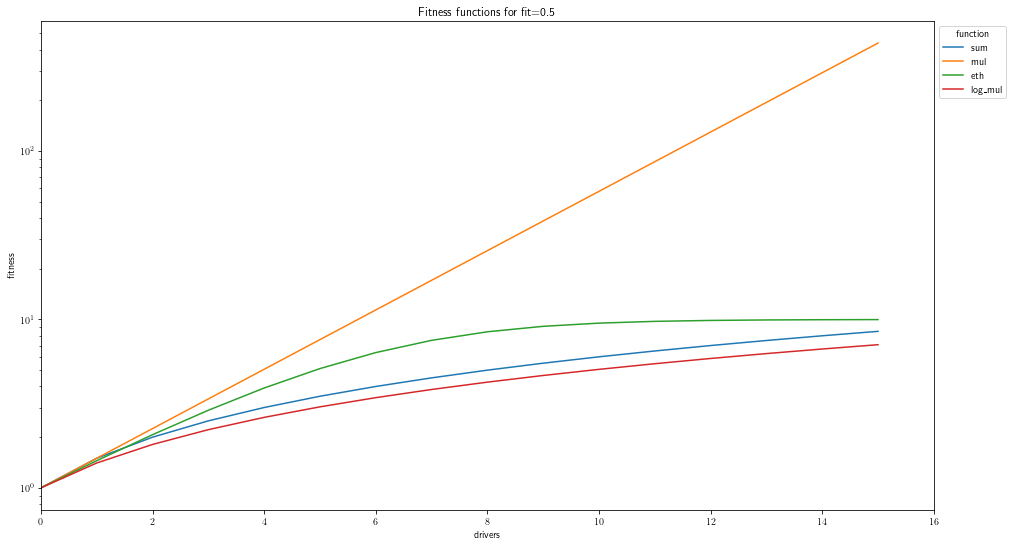

In [61]:
steps = list(range(0, 16))

fit = 0.5
plt.plot(steps, sum_fit(16, fit))
plt.plot(steps, mul_fit(16, fit))
plt.plot(steps, eth_fit(16, fit))
plt.plot(steps, log_mul_fit(16, fit))

plt.yscale('log')
plt.ylabel('fitness')
plt.xlabel('drivers')
plt.xlim(0, 16)
plt.legend(['sum', 'mul', 'eth', 'log_mul'], loc='upper left', title='function',  bbox_to_anchor=(1, 1))

# title 
plt.title(f'Fitness functions for fit={fit}')

# save the plot as a PNG
plt.savefig('figures/fitness_functions3.png', bbox_inches = 'tight')